# Magnons of the Heusler Ag$_2$NdCd from SIESTA, with waw's native LKAG

The magnetism of a rare-earth intermetallic sits in a shell that most
pseudopotentials throw away.  Ag$_2$NdCd (full Heusler, $Fm\bar{3}m$,
$a = 7.144$ Å) has Ag $4d^{10}$ and Cd $4d^{10}$ — both closed — so every
moment in the compound comes from Nd $4f^3$.  Whether the calculation can see
that at all is decided before any SCF cycle runs, by which pseudopotential is
picked.

The route here is the one notebook 18 established for bcc Fe, with no
Wannierization anywhere:

$$\text{SIESTA} \;\to\; H(k),S(k)\ \text{(NAO)} \;\to\; \text{Löwdin} \;\to\;
H(R) \;\to\; \text{LKAG} \;\to\; J_{ij}(R) \;\to\; \text{LSWT magnons}$$

waw's `heisenberg_exchange` is certified against TB2J to $5\times10^{-8}$ eV on
identical Fe input, so this reproduces the `siesta2J.py` leg of `run-magnons.py`
natively, with the intermediate $J_{ij}(R)$ and the Green's-function moments
exposed rather than written to disk and re-read.

**Nd and Ag are the magnetic sublattices.**  Nd sits on $4b$ and carries the
$4f^3$ moment; Ag sits on the $8c$ site, so the primitive cell holds *two*
crystallographically equivalent Ag atoms and the model has **three** sublattices,
hence three magnon branches.  Ag $4d^{10}5s^1$ is nominally closed, but $8c$ is
the site that hybridizes with both neighbours in a full Heusler, so an induced
moment there is something to measure rather than assume away.  Cd ($4d^{10}5s^2$,
$4a$) is left out of the exchange model.

In [1]:
import os, sys, re, json, shutil, pathlib
import numpy as np
import matplotlib.pyplot as plt

HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
waw.set_num_threads(16)
from ase.io import read
from waw.interfaces import siesta as sst
from waw.interfaces.ase.structure import band_path
from waw.analysis.elph import band_eigensystem
from waw.analysis.exchange import heisenberg_exchange
from waw.analysis.bands import band_path_fidelity
from waw.analysis.magnon import magnon_bands
from waw.vis.bands import plot_bands, BandSeries
from waw.units import HARTREE_TO_EV

# --- one place to change when adding a compound ---------------------------
CIF        = REPO / 'workflows/notebooks/data/Ag2NdCd_agm002132770.cif'
LABEL      = 'ag2ndcd'
MAGNETIC   = ('Nd', 'Ag')      # elements carried into the exchange model
                               # (every atom of each becomes a sublattice)
KSPACING   = 0.15              # A^-1, as in run-magnons.py
MESH_HINT  = 'hh'              # PseudoDojo hint level: hl / hn / hh
MESH_FACTOR = 4.0              # wavefunction cutoff -> density cutoff (see below)
DOJO_JSON  = pathlib.Path.home() / 'siesta/nc-fr-04_pbe_standard.json'
BASIS      = 'DZP'

# PseudoDojo nc-fr-04 PBE standard. Nd MUST come from the lanthanide set:
# the general set's Nd is the trivalent pseudo with 4f frozen in the core.
PP_LANTH   = pathlib.Path.home() / 'siesta/nc-fr-04_pbe_standard_psml'
PP_GENERAL = pathlib.Path.home() / 'siesta/nc-fr-04_pbe_standard'
INIT_MOM   = {'Nd': 3.62}      # run-magnons.py def_magmom; others take 0.5
INIT_MOM_DEFAULT = 0.5

def mesh_cutoff_ry(symbols, hint=MESH_HINT, factor=MESH_FACTOR, dojo=DOJO_JSON):
    '''SIESTA MeshCutoff (Ry) from the PseudoDojo plane-wave hints.

    The hints are WAVEFUNCTION cutoffs in Hartree, meant for a plane-wave
    code. SIESTA has no wavefunction cutoff at all -- MeshCutoff is the
    cutoff of the real-space grid that carries the DENSITY and potential.
    Since rho ~ |psi|^2 needs Fourier components out to twice the
    wavefunction's G_max, the equivalent density cutoff is 4x:

        MeshCutoff[Ry] = factor * 2 * max_El hint[Ha]
                           |      |
                           |      Ha -> Ry
                           rho ~ |psi|^2

    factor = 1 reproduces the mapping that sets MeshCutoff to the
    wavefunction cutoff re-expressed in Ry, which lands 4x low.
    '''
    d = json.loads(pathlib.Path(dojo).read_text())
    return factor * 2.0 * max(d[s][hint] for s in set(symbols))


print('waw threads =', waw.get_num_threads())

waw threads = 16


## The structure

The CIF is the 16-atom conventional cell.  Everything below runs in the
4-atom primitive cell that `spglib` standardises to — one Nd, one Cd, two Ag —
which is what `run-magnons.py` also does, and the k-grid follows the same
`kspacing` rule.

In [2]:
import spglib

conv = read(CIF)
cell_in = (conv.get_cell()[:], conv.get_scaled_positions(), conv.get_atomic_numbers())
print(f'CIF: {conv.get_chemical_formula()}, {len(conv)} atoms, '
      f'spacegroup {spglib.get_spacegroup(cell_in, symprec=0.1)}')

lat, pos, num = spglib.standardize_cell(cell_in, to_primitive=True, symprec=0.1)
from ase import Atoms
atoms = Atoms(numbers=num, scaled_positions=pos, cell=lat, pbc=True)
atoms = atoms[np.argsort(-atoms.get_atomic_numbers())]        # Nd, Cd, Ag, Ag
CELL = atoms.get_cell()[:]
SYMBOLS = atoms.get_chemical_symbols()

recip = 2 * np.pi * np.linalg.inv(CELL).T
kp = [int(np.ceil(l / KSPACING)) for l in np.linalg.norm(recip, axis=1)]
KGRID = tuple(k if k % 2 == 0 else k + 1 for k in kp)

MESH_RY = mesh_cutoff_ry(SYMBOLS)
# the workdir carries the cutoff: run_siesta skips a completed run, so a
# shared directory would silently serve a stale mesh
W = REPO / 'workflows/notebooks/runs' / f'{LABEL}_mesh{int(MESH_RY)}'
W.mkdir(parents=True, exist_ok=True)

print(f'primitive: {atoms.get_chemical_formula()}, {len(atoms)} atoms  -> {SYMBOLS}')
print(f'nearest-neighbour Nd-Nd = {np.linalg.norm(CELL[0]):.3f} A   (fcc sublattice)')
print(f'k-grid at kspacing {KSPACING} = {KGRID}')
_d = json.loads(DOJO_JSON.read_text())
print(f'PseudoDojo {MESH_HINT} hints (Ha, wavefunction): '
      + ', '.join(f'{s} {_d[s][MESH_HINT]:.0f}' for s in sorted(set(SYMBOLS))))
print(f'MeshCutoff = {MESH_FACTOR:g} x 2 x {max(_d[s][MESH_HINT] for s in set(SYMBOLS)):.0f} Ha'
      f' = {MESH_RY:.0f} Ry  (density grid)')

CIF: Ag8Cd4Nd4, 16 atoms, spacegroup Fm-3m (225)
primitive: Ag2CdNd, 4 atoms  -> ['Nd', 'Cd', 'Ag', 'Ag']
nearest-neighbour Nd-Nd = 5.052 A   (fcc sublattice)
k-grid at kspacing 0.15 = (12, 12, 12)
PseudoDojo hh hints (Ha, wavefunction): Ag 47, Cd 57, Nd 102
MeshCutoff = 4 x 2 x 102 Ha = 816 Ry  (density grid)


### The mesh cutoff is a *density* cutoff

PseudoDojo's `hl/hn/hh` hints are plane-wave **wavefunction** cutoffs in
Hartree — the ABINIT `ecut` at which that pseudopotential is converged.  SIESTA
has no wavefunction cutoff at all: its basis is numerical atomic orbitals, and
`MeshCutoff` is the cutoff of the real-space grid carrying the **density** and
potential.  Since $\rho\sim|\psi|^2$ needs Fourier components out to twice the
wavefunction's $G_{\max}$, the equivalent density cutoff is $4\times$ the
wavefunction one:

$$\texttt{MeshCutoff}\,[\mathrm{Ry}] \;=\; 4 \times 2 \times
\max_{\rm El}\ \texttt{hint}\,[\mathrm{Ha}]$$

the 2 being Ha $\to$ Ry.  For Nd ($hh = 102$ Ha, the hardest of the three
species) that gives **816 Ry**.  Feeding the hint straight in as the mesh
cutoff — which is easy to do, since both are "the cutoff" — sets it to the
wavefunction value re-expressed in Ry, i.e. $4\times$ too low.

Measured on this compound, against a 1000 Ry reference:

| MeshCutoff | grid | $\Delta E$/atom | $|S|$ ($\mu_B$) | wall |
|---|---|---|---|---|
| 204 Ry (= the hint, 4$\times$ low) | $36^3$ | $-12.6$ meV | 3.8360 | 532 s |
| 400 Ry | $50^3$ | $+2.4$ meV | 3.8361 | 455 s |
| 600 Ry | $64^3$ | $+0.8$ meV | 3.8359 | 474 s |
| **816 Ry** (the rule) | $72^3$ | $+0.2$ meV | 3.8359 | 490 s |
| 1000 Ry | $80^3$ | — | 3.8358 | 467 s |

Two things worth keeping.  The **moment is insensitive** — 3.8358–3.8361 $\mu_B$
across a 5$\times$ range — so the exchange and the magnons are safe even at the
low cutoff; only the total energy suffers, and non-monotonically, which is the
usual aliasing signature of an under-resolved grid.  And the **cost is flat**
here: 467–532 s regardless, because a 4-atom cell is dominated by diagonalising
1728 k-points, not by the mesh FFT.  When the grid is that cheap there is no
reason to economise, so the rule is applied as the default rather than tuned
down.  In a large cell, where the mesh does dominate, this table is the argument
for converging it rather than trusting a rule of thumb.

## Which Nd pseudopotential — the decision that settles the whole calculation

PseudoDojo ships two Nd entries and they describe different physics:

| set | valence | 4f | magnetism |
|---|---|---|---|
| `nc-fr-04_pbe_standard` (general, 83 elements) | 11 e$^-$: $5s^2 5p^6 5d^1 6s^2$ | **frozen in the core** | none |
| `nc-fr-04_pbe_standard_psml` (lanthanides, 13) | 14 e$^-$: $5s^2 5p^6 5d^1 6s^2 + 4f^3$ | **in valence** | Nd $4f^3$ |

The trivalent pseudo is the right object for a lanthanide whose $4f$ shell is a
spectator, and the wrong one here: with $4f$ in the core the shell is spin-paired
by construction, Nd carries no moment, and the magnon spectrum is empty.  Only
Nd needs the lanthanide set; Ag and Cd are taken from the general one, both
being the same `nc-fr-04` PBE generation, so the three are consistent.

The cell below asserts the valence charge rather than trusting the path, because
the two files have the same name and differ only in a directory.

In [3]:
PP = W / 'pseudos'
PP.mkdir(exist_ok=True)
src = {s: (PP_LANTH if s == 'Nd' else PP_GENERAL) / f'{s}.psml'
       for s in sorted(set(SYMBOLS))}
for s, p in src.items():
    shutil.copy2(p, PP / f'{s}.psml')

EXPECTED_Z = {'Nd': 14.0, 'Cd': 20.0, 'Ag': 19.0}
for s in sorted(set(SYMBOLS)):
    t = (PP / f'{s}.psml').read_text()
    z = float(re.search(r'valence-charge="([\d.]+)"', t).group(1))
    rel = re.search(r'relativity="(\w+)"', t).group(1)
    shells = re.findall(r'<shell\s+n="(\d+)"\s+l="(\w+)"\s+occupation="([\d.]+)"', t)
    cfg = ' '.join(f'{n}{l}^{float(o):g}' for n, l, o in shells)
    print(f'{s}: z_val = {z:5.1f}  rel = {rel:6s}  {cfg}')
    assert z == EXPECTED_Z[s], f'{s}: expected {EXPECTED_Z[s]} valence electrons, got {z}'
assert any(l == 'f' for _, l, _ in re.findall(
    r'<shell\s+n="(\d+)"\s+l="(\w+)"\s+occupation="([\d.]+)"',
    (PP / 'Nd.psml').read_text())), 'Nd 4f is not in valence -- wrong pseudopotential'
print('\nNd 4f is in valence: the compound can be magnetic.')

Ag: z_val =  19.0  rel = dirac   4s^2 4p^6 4d^10 5s^1
Cd: z_val =  20.0  rel = dirac   4s^2 4p^6 4d^10 5s^2
Nd: z_val =  14.0  rel = dirac   5s^2 5p^6 5d^1 6s^2 4f^3

Nd 4f is in valence: the compound can be magnetic.


## SCF

Collinear spin, PBE, DZP.  Every atom starts with a moment — Nd at 3.62 $\mu_B$
(the `run-magnons.py` value, close to the $4f^3$ spin-only 3 $\mu_B$), Cd and Ag
at the 0.5 default — so nothing is prevented from polarising.  The Pulay mixer
settings are the ones that workflow uses; $4f$ states at $E_F$ make plain
mixing unreliable.

Note the $4f$ are treated as ordinary valence states in PBE, with no $U$ and no
open-core constraint, exactly as `run-magnons.py` does.  That is the convention
being reproduced here, not a claim that it is the best description of a
localized $4f^3$ shell.

In [4]:
moments = {i: INIT_MOM.get(s, INIT_MOM_DEFAULT) for i, s in enumerate(SYMBOLS)}
print('initial moments:', {SYMBOLS[i]: m for i, m in moments.items()})

fdf = sst.write_fdf(
    W / f'{LABEL}.fdf', atoms, label=LABEL, pseudo_dir=PP,
    kgrid=KGRID, spin='polarized', basis=BASIS, xc='PBE',
    mesh_cutoff_ry=MESH_RY, initial_moments=moments,
    extra={'SCF.Mixer.Method': 'Pulay', 'SCF.Mixer.History': 16,
           'SCF.Mixer.Weight': 0.4, 'SCF.Mixer.Spin': 'sum',
           'Max.SCF.Iterations': 200, 'SCFMustConverge': 'T',
           'Charge.Mulliken': 'end'})
sst.run_siesta(fdf, ncores=16)          # cached: skips if <label>.out completed

H = sst.load_hamiltonian(W / f'{LABEL}.fdf')
print(f'spin: {H.spin}   NAOs: {H.no}')
for ia, s in enumerate(SYMBOLS):
    orbs = [o.name() for o in H.geometry.atoms[ia].orbitals]
    print(f'  {s}: {len(orbs):2d} NAOs  {", ".join(orbs)}')

initial moments: {'Nd': 3.62, 'Cd': 0.5, 'Ag': 0.5}


spin: Spin{polarized}   NAOs: 80
  Nd: 23 NAOs  5sZ1, 6sZ1, 6sZ2, 5pyZ1, 5pzZ1, 5pxZ1, 6pyZ1, 6pzZ1, 6pxZ1, 4fy(3x2-y2)Z1, 4fxyzZ1, 4fz2yZ1, 4fz3Z1, 4fz2xZ1, 4fz(x2-y2)Z1, 4fx(x2-3y2)Z1, 4fy(3x2-y2)Z2, 4fxyzZ2, 4fz2yZ2, 4fz3Z2, 4fz2xZ2, 4fz(x2-y2)Z2, 4fx(x2-3y2)Z2
  Cd: 19 NAOs  4sZ1, 5sZ1, 5sZ2, 4pyZ1, 4pzZ1, 4pxZ1, 5pyZ1, 5pzZ1, 5pxZ1, 4dxyZ1, 4dyzZ1, 4dz2Z1, 4dxzZ1, 4dx2-y2Z1, 4dxyZ2, 4dyzZ2, 4dz2Z2, 4dxzZ2, 4dx2-y2Z2
  Ag: 19 NAOs  4sZ1, 5sZ1, 5sZ2, 4pyZ1, 4pzZ1, 4pxZ1, 5pyZ1, 5pzZ1, 5pxZ1, 4dxyZ1, 4dyzZ1, 4dz2Z1, 4dxzZ1, 4dx2-y2Z1, 4dxyZ2, 4dyzZ2, 4dz2Z2, 4dxzZ2, 4dx2-y2Z2
  Ag: 19 NAOs  4sZ1, 5sZ1, 5sZ2, 4pyZ1, 4pzZ1, 4pxZ1, 5pyZ1, 5pzZ1, 5pxZ1, 4dxyZ1, 4dyzZ1, 4dz2Z1, 4dxzZ1, 4dx2-y2Z1, 4dxyZ2, 4dyzZ2, 4dz2Z2, 4dxzZ2, 4dx2-y2Z2


### Did it actually polarise?

`run-magnons.py` stops when no atom carries more than 0.25 $\mu_B$, on the
grounds that a Heisenberg model built on a non-magnetic ground state is
meaningless.  The same gate applies here, read from the Mulliken block.

In [5]:
out = (W / f'{LABEL}.out').read_text().splitlines()
tot = [l for l in out if 'spin moment' in l.lower()]
if tot:
    print('SIESTA total spin moment line:', tot[-1].strip())

mull = {}
for i, l in enumerate(out):
    if l.strip().startswith('mulliken: Atomic and Orbital Populations') or \
       l.strip() == 'Mulliken Atomic Populations:':
        for l2 in out[i:i + 400]:
            m = re.match(r'\s*(\d+)\s+([-\d.]+)\s+([-\d.]+)\s+([-\d.]+)\s*$', l2)
            if m:
                ia = int(m.group(1)) - 1
                if ia < len(SYMBOLS):
                    mull[ia] = float(m.group(4))
if mull:
    for ia, mm in sorted(mull.items()):
        print(f'  {SYMBOLS[ia]:2s} (atom {ia}): Mulliken moment {mm:+.3f} mu_B')
    assert any(abs(m) > 0.25 for m in mull.values()), \
        'no atom carries >0.25 mu_B -- the system is not magnetic'
else:
    print('(Mulliken block not parsed; the Green-function moments below are '
          'the authoritative check)')

SIESTA total spin moment line: spin moment: {S} , |S| = {        0.0        0.0    3.83588 }     3.83588
(Mulliken block not parsed; the Green-function moments below are the authoritative check)


## Löwdin $H(R)$, and whether it interpolates

The NAO basis is non-orthogonal, so $H(k), S(k) \to S^{-1/2} H S^{-1/2}$ gives an
orthogonal model that every $H$-only analysis in waw consumes unchanged.

The check that matters is **off-mesh**.  A model reproduces its own mesh by
construction, so agreement there says nothing; `band_path_fidelity` compares the
interpolated bands against the exact NAO eigenvalues along a path, which is where
a model that has been Fourier-transformed from too coarse a mesh falls apart.
This is the guard notebook 22's QE route lacked.

off-mesh interpolation error vs the exact NAO H(k), states within +-3 eV of E_F (HSX: E_F = 0):


  8^3: max   94.40 meV   rms   9.55   max@E_F   94.40 meV   (2126 states)


  10^3: max   32.92 meV   rms   4.08   max@E_F   32.92 meV   (2126 states)


  12^3: max   15.69 meV   rms   1.21   max@E_F   15.69 meV   (2126 states)


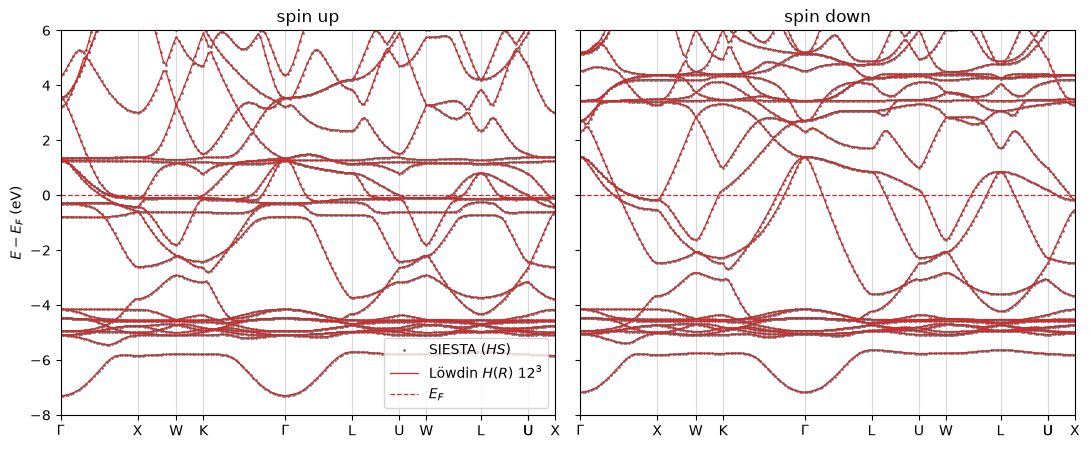

In [6]:
bp = band_path(atoms, npoints=200)
x, xt, xl = bp.get_linear_kpoint_axis()
hr = {sp: sst.lowdin_hamiltonian(H, KGRID, spin=sp) for sp in (0, 1)}

print(f'off-mesh interpolation error vs the exact NAO H(k), '
      f'states within +-3 eV of E_F (HSX: E_F = 0):')
for n in (8, 10, 12):
    e_ref = np.array([H.eigh(k, spin=0) for k in bp.kpts])
    e_w = band_eigensystem(sst.lowdin_hamiltonian(H, (n, n, n), spin=0),
                           bp.kpts)[0] * HARTREE_TO_EV
    f = band_path_fidelity(e_w, e_ref, window=(-3.0, 3.0), fermi_ev=0.0)
    print(f'  {n}^3: max {f["max"]:7.2f} meV   rms {f["rms"]:6.2f}   '
          f'max@E_F {f["max_near_ef"]:7.2f} meV   ({f["n_states"]} states)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
labels = [l.replace('G', r'$\Gamma$') for l in xl]
for ax, sp in zip(axes, (0, 1)):
    e_ref = np.array([H.eigh(k, spin=sp) for k in bp.kpts])
    e_w = band_eigensystem(hr[sp], bp.kpts)[0] * HARTREE_TO_EV
    plot_bands(x, xt, labels,
               [BandSeries(e_ref, label='SIESTA ($HS$)', color='0.45',
                           plot_kw=dict(ls='none', marker='.', ms=2.0, zorder=1)),
                BandSeries(e_w, label=f'Löwdin $H(R)$ ${KGRID[0]}^3$', color='C3',
                           plot_kw=dict(lw=0.9, zorder=2))],
               ax=ax, ref_line=0.0, ref_label='$E_F$', ylim=(-8, 6),
               ylabel=r'$E - E_F$ (eV)' if sp == 0 else '',
               title=f'spin {"up" if sp == 0 else "down"}',
               legend=(sp == 0))
plt.tight_layout(); plt.show()

## Exchange

LKAG on the two spin channels.  Each magnetic sublattice is one group of NAO
indices; both Nd and Cd are carried, so $J$ comes back as a $2\times2$ set of
sublattice pairs at every lattice vector.

For Nd the moment lives in $4f$, so the $4f$-only group is the physically
meaningful one; the all-orbital group is shown beside it because on Fe the two
differed by a factor that mattered (notebook 18), and because a $4f$ block that
hybridizes strongly will show it as a gap between the two.

In [7]:
g = np.meshgrid(*[np.arange(n) for n in KGRID], indexing='ij')
kpts = np.stack([v.ravel() for v in g], axis=1) / np.array(KGRID)

Rbox = np.array([(i, j, k) for i in range(-3, 4) for j in range(-3, 4)
                 for k in range(-3, 4)])
R_CUT = 12.0
Rl = Rbox[np.linalg.norm(Rbox @ CELL, axis=1) <= R_CUT]
print(f'{len(Rl)} lattice vectors within {R_CUT} A')

def orbs_of(ia, pattern=None):
    o = list(H.geometry.a2o(ia, all=True))
    if pattern is None:
        return o
    names = [x.name() for x in H.geometry.atoms[ia].orbitals]
    return [o[k] for k, nm in enumerate(names) if pattern in nm]

MAG_ATOMS = [ia for ia, s in enumerate(SYMBOLS) if s in MAGNETIC]
SUBLAT = [f'{SYMBOLS[ia]}{ia}' for ia in MAG_ATOMS]
print(f'magnetic sublattices: {SUBLAT}  ({len(SUBLAT)} -> that many magnon branches)')

groups_f   = [orbs_of(ia, '4f') if SYMBOLS[ia] == 'Nd' else orbs_of(ia)
              for ia in MAG_ATOMS]
groups_all = [orbs_of(ia) for ia in MAG_ATOMS]
for lab, g in zip(SUBLAT, groups_f):
    print(f'  {lab}: {len(g)} NAOs in the restricted group')

res = {}
for tag, grp in (('Nd 4f only', groups_f), ('all orbitals', groups_all)):
    res[tag] = heisenberg_exchange(hr[0], hr[1], kpts, 0.0, grp, Rl, nz=100)
    print(f'{tag:13s} moments (mu_B): ' +
          '  '.join(f'{SUBLAT[i]} {m:+.3f}' for i, m in enumerate(res[tag].magmoms)))

79 lattice vectors within 12.0 A
magnetic sublattices: ['Nd0', 'Ag2', 'Ag3']  (3 -> that many magnon branches)
  Nd0: 14 NAOs in the restricted group
  Ag2: 19 NAOs in the restricted group
  Ag3: 19 NAOs in the restricted group


Nd 4f only    moments (mu_B): Nd0 +3.500  Ag2 +0.039  Ag3 +0.039


all orbitals  moments (mu_B): Nd0 +3.551  Ag2 +0.039  Ag3 +0.039


In [8]:
POS = atoms.get_positions()

def shells(r, a, b, imax=3):
    '''J between sublattices a and b, grouped by the true interatomic distance.'''
    out = {}
    for (R, i, j), v in r.J.items():
        if (i, j) != (a, b):
            continue
        d = float(np.linalg.norm(np.array(R) @ CELL + POS[MAG_ATOMS[j]]
                                 - POS[MAG_ATOMS[i]]))
        if d > 1e-6:
            out.setdefault(round(d, 3), []).append(v * HARTREE_TO_EV * 1e3)
    return sorted(out.items())[:imax]

for tag, r in res.items():
    print(f'--- {tag} ---')
    for a in range(len(SUBLAT)):
        for b in range(a, len(SUBLAT)):
            sh = shells(r, a, b)
            if not sh:
                continue
            row = '  '.join(f'{d:5.2f} A: {np.mean(v):8.4f}' for d, v in sh)
            print(f'  {SUBLAT[a]:>5s}-{SUBLAT[b]:<5s} {row}   [meV]')

--- Nd 4f only ---
    Nd0-Nd0    5.05 A:  -0.4432   7.14 A:  -0.0220   8.75 A:  -0.0064   [meV]
    Nd0-Ag2    3.09 A:   0.1496   5.92 A:  -0.0054   7.79 A:  -0.0035   [meV]
    Nd0-Ag3    3.09 A:   0.1496   5.92 A:  -0.0054   7.79 A:  -0.0035   [meV]
    Ag2-Ag2    5.05 A:   0.0021   7.14 A:  -0.0005   8.75 A:  -0.0001   [meV]
    Ag2-Ag3    3.57 A:   0.0002   6.19 A:   0.0037   7.99 A:   0.0000   [meV]
    Ag3-Ag3    5.05 A:   0.0021   7.14 A:  -0.0005   8.75 A:  -0.0001   [meV]
--- all orbitals ---
    Nd0-Nd0    5.05 A:  -0.5550   7.14 A:   0.0595   8.75 A:   0.0519   [meV]
    Nd0-Ag2    3.09 A:   0.2804   5.92 A:   0.0022   7.79 A:  -0.0041   [meV]
    Nd0-Ag3    3.09 A:   0.2804   5.92 A:   0.0022   7.79 A:  -0.0041   [meV]
    Ag2-Ag2    5.05 A:   0.0021   7.14 A:  -0.0005   8.75 A:  -0.0001   [meV]
    Ag2-Ag3    3.57 A:   0.0002   6.19 A:   0.0037   7.99 A:   0.0000   [meV]
    Ag3-Ag3    5.05 A:   0.0021   7.14 A:  -0.0005   8.75 A:  -0.0001   [meV]


## Magnon spectrum

Linear spin-wave theory on the converged $J_{ij}(R)$.  Three sublattices (Nd, and the two
$8c$ Ag) give three branches; if the Ag moments are negligible their branches
carry no dispersion and the Nd fcc sublattice alone sets the spectrum.

Nd 4f only     branch maxima (meV):    0.000    60.418    63.386   min =   -6.328
all orbitals   branch maxima (meV):    0.607   124.375   127.343   min =   -5.100


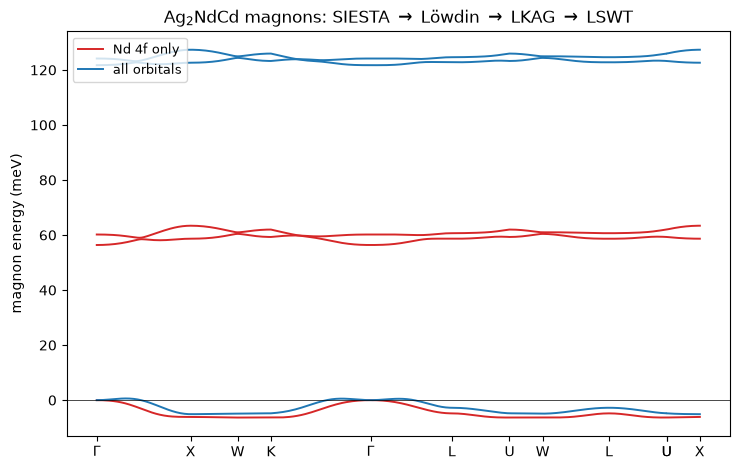

In [9]:
bpm = band_path(atoms, npoints=300)
xm, xmt, xml = bpm.get_linear_kpoint_axis()

fig, ax = plt.subplots(figsize=(7.5, 4.8))
for (tag, r), c in zip(res.items(), ('C3', 'C0')):
    w = magnon_bands(r.J, np.asarray(r.magmoms), bpm.kpts) * HARTREE_TO_EV * 1e3
    for b in range(w.shape[1]):
        ax.plot(xm, w[:, b], color=c, lw=1.4,
                label=tag if b == 0 else None)
    print(f'{tag:14s} branch maxima (meV): '
          + '  '.join(f'{w[:, b].max():8.3f}' for b in range(w.shape[1]))
          + f'   min = {w.min():+8.3f}')
ax.set_xticks(xmt); ax.set_xticklabels([l.replace('G', r'$\Gamma$') for l in xml])
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('magnon energy (meV)')
ax.set_title(r'Ag$_2$NdCd magnons: SIESTA $\to$ Löwdin $\to$ LKAG $\to$ LSWT')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## How to take a weakly polarized sublattice into account

Ag does polarise — $+0.039\,\mu_B$ against Nd's $3.5$ — so leaving it out is a
choice that has to be justified, not a default.  But a magnon energy goes as
$J/S$, and the LSWT matrix elements here as $J_{ij}/\sqrt{S_i S_j}$, so a small
moment does **not** give a small correction: it gives a large one.  Treating the
two Ag atoms as independent spins puts two flat branches at 60–120 meV, an order
of magnitude above the Nd magnons, purely because $S_{\rm Ag}\approx0.02$ sits in
a denominator.  Those branches are the precession of a nearly-zero moment — fast,
decoupled from the Nd dynamics, and not something a neutron would see.

Three treatments, in increasing completeness:

1. **Leave Ag out of the exchange model.**  Its polarization still enters the
   Green's functions that produce $J_{\rm Nd\text{-}Nd}$, but its spin is held
   fixed while the Nd moments are rotated — the *frozen-ligand* limit.
2. **Keep Ag as full branches.**  Correct only when the moments are comparable.
   Here it is not.
3. **Compute the Ag couplings, then downfold them.**  The induced moments are
   eliminated adiabatically, so they mediate Nd–Nd coupling without contributing
   branches — the *relaxed-ligand* limit.

(1) and (3) differ by exactly the Ag-mediated path, and that difference is the
physical content of "taking the other polarized atoms into account".  It need not
be small: downfolding the iodine moments in NiI$_2$ changed $J_1$ by ~90$\times$.

The check that the downfolding is right: for a collinear ferromagnet the
anomalous Bogoliubov block vanishes, so eliminating the Ag rows and columns of
the LSWT matrix at $\omega\to0$ is an ordinary Schur complement, and the single
downfolded branch must lie on top of the acoustic branch of the full
three-branch calculation.  That is asserted below rather than assumed.

In [10]:
# treatment 1: Nd alone in the exchange model (Ag frozen)
res_nd = heisenberg_exchange(hr[0], hr[1], kpts, 0.0,
                             [orbs_of(MAG_ATOMS[0], '4f')], Rl, nz=100)
print(f'Nd-only model: moment {res_nd.magmoms[0]:+.3f} mu_B')

r_full = res['Nd 4f only']
m_full = np.asarray(r_full.magmoms)
AG = [i for i, lab in enumerate(SUBLAT) if lab.startswith('Ag')]
print(f'downfolding sublattices {[SUBLAT[i] for i in AG]} '
      f'(S = {np.abs(m_full[AG])/2} vs Nd {abs(m_full[0])/2:.3f})')

w_full = magnon_bands(r_full.J, m_full, bpm.kpts) * HARTREE_TO_EV * 1e3
w_down = magnon_bands(r_full.J, m_full, bpm.kpts,
                      downfold=AG) * HARTREE_TO_EV * 1e3
w_ndon = magnon_bands(res_nd.J, np.asarray(res_nd.magmoms),
                      bpm.kpts) * HARTREE_TO_EV * 1e3

dev = np.abs(w_down[:, 0] - w_full[:, 0]).max()
print(f'\ndownfolded branch vs the acoustic branch of the full model: '
      f'max |diff| = {dev:.4f} meV')
assert dev < 0.05 * max(1e-9, np.ptp(w_full[:, 0])), \
    'downfolding does not reproduce the acoustic branch'

print(f'\nbandwidth of the Nd branch (meV):')
print(f'  1. Nd only, Ag frozen        {np.ptp(w_ndon[:, 0]):8.3f}   '
      f'min {w_ndon[:, 0].min():+8.3f}')
print(f'  3. Nd + Ag downfolded        {np.ptp(w_down[:, 0]):8.3f}   '
      f'min {w_down[:, 0].min():+8.3f}')
print(f'  (2. full model, Ag branches at '
      f'{w_full[:, 1:].min():.1f}-{w_full[:, 1:].max():.1f} meV)')
print(f'\nAg-mediated contribution to the bandwidth: '
      f'{np.ptp(w_down[:, 0]) - np.ptp(w_ndon[:, 0]):+.3f} meV '
      f'({100*(np.ptp(w_down[:, 0])/max(np.ptp(w_ndon[:, 0]), 1e-12) - 1):+.1f}%)')

Nd-only model: moment +3.500 mu_B
downfolding sublattices ['Ag2', 'Ag3'] (S = [0.01952514 0.01952514] vs Nd 1.750)

downfolded branch vs the acoustic branch of the full model: max |diff| = 0.0415 meV

bandwidth of the Nd branch (meV):
  1. Nd only, Ag frozen           7.558   min   -7.558
  3. Nd + Ag downfolded           6.336   min   -6.336
  (2. full model, Ag branches at 56.4-63.4 meV)

Ag-mediated contribution to the bandwidth: -1.222 meV (-16.2%)


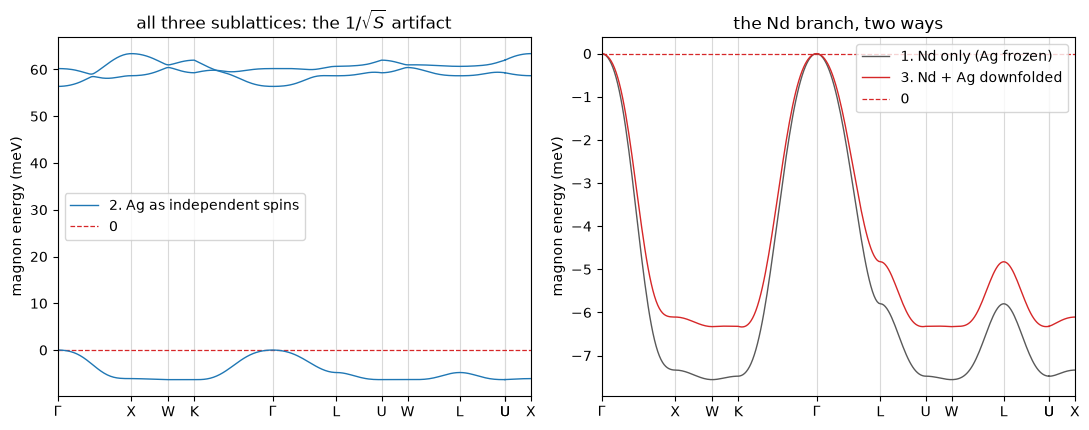

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

plot_bands(xm, xmt, [l.replace('G', r'$\Gamma$') for l in xml],
           [BandSeries(w_full, label='2. Ag as independent spins', color='C0')],
           ax=axes[0], ref_line=0.0, ref_label='0',
           ylabel='magnon energy (meV)',
           title='all three sublattices: the $1/\\sqrt{S}$ artifact')

plot_bands(xm, xmt, [l.replace('G', r'$\Gamma$') for l in xml],
           [BandSeries(w_ndon, label='1. Nd only (Ag frozen)', color='0.35'),
            BandSeries(w_down, label='3. Nd + Ag downfolded', color='C3')],
           ax=axes[1], ref_line=0.0, ref_label='0',
           ylabel='magnon energy (meV)',
           title='the Nd branch, two ways')
plt.tight_layout(); plt.show()

## The ferromagnet is not the ground state — following the imaginary modes

Every branch above runs **negative** over part of the path, and that is not a
numerical blemish to be tuned away.  In LSWT the grand matrix $h(\mathbf q)$ of
Toth & Lake is positive semi-definite **iff** the assumed classical state is a local
minimum, so a negative eigenvalue at $\mathbf q$ names a spin-wave costing less than
the reference state — and simultaneously names the modulation to adopt instead.

That is the construction of Romero *et al.*, *npj Comput. Mater.* ("systematic
determination of a material's magnetic ground state from first principles"): locate
the $\mathbf q^\*$ minimising the lowest eigenvalue, convert it to the smallest
commensurate supercell, build the broken-symmetry cell, re-converge, and check.
`waw.analysis.magnon` implements both halves — `propagation_vector` searches
$\mathbf q^\*$ on a mesh with refinement, `commensurate_supercell` turns it into a
supercell matrix plus the $\pm$ sign pattern.

The construction earns its name only if **all three** of these hold, so all three are
tested below:

1. the new cell **converges** where the ferromagnet does not,
2. it is **lower in energy**, and
3. its magnons are **real**.

Note that (3) is not automatic given (1) and (2): a cell can be a local minimum of the
SCF and still be unstable against a longer-period modulation the supercell cannot
represent.


In [12]:
from waw.analysis.magnon import propagation_vector, commensurate_supercell

r_ex = res['all orbitals']
pv = propagation_vector(r_ex.J, np.asarray(r_ex.magmoms), mesh=16)
print(f"reference (ferromagnetic) state stable: {pv['stable']}")
print(f"q* = {np.round(pv['q'], 4)}    "
      f"lambda_min = {pv['lambda_min'] * HARTREE_TO_EV * 1e3:+.4f} meV    "
      f"lambda(0) = {pv['lambda_at_0'] * HARTREE_TO_EV * 1e3:+.4f} meV")

csc = commensurate_supercell(pv['q'])
D, TRANS, SIGNS = csc['supercell'], csc['translations'], csc['signs']
print(f"\n-> supercell {D.tolist()}  exact={csc['exact']}")
print(f"   translations {TRANS.tolist()}")
print(f"   signs        {SIGNS.tolist()}")

# build the broken-symmetry cell explicitly, so the spin pattern maps to
# known atom indices rather than to whatever order a supercell helper emits
sc_sym, sc_pos, sc_sign = [], [], []
for t, s in zip(TRANS, SIGNS):
    off = t @ CELL
    for a in atoms:
        sc_sym.append(a.symbol)
        sc_pos.append(a.position + off)
        sc_sign.append(s if a.symbol == 'Nd' else 0)
SC = Atoms(symbols=sc_sym, positions=sc_pos, cell=(D[:, None] * CELL), pbc=True)
SC_SIGN = np.array(sc_sign)
ND_SC = [i for i, s in enumerate(SC.get_chemical_symbols()) if s == 'Nd']

rec_sc = 2 * np.pi * np.linalg.inv(SC.get_cell()[:]).T
KG_SC = tuple(max(1, int(np.ceil(l / KSPACING)) // 2 * 2)
              for l in np.linalg.norm(rec_sc, axis=1))
print(f"\nsupercell: {SC.get_chemical_formula()}, {len(SC)} atoms, "
      f"Nd at {ND_SC} with pattern {SC_SIGN[ND_SC].tolist()}")
print(f"k-grid {KG_SC}")


reference (ferromagnetic) state stable: False
q* = [0.5 0.5 0. ]    lambda_min = -5.1003 meV    lambda(0) = +0.0000 meV

-> supercell [2, 2, 1]  exact=True
   translations [[0, 0, 0], [0, 1, 0], [1, 0, 0], [1, 1, 0]]
   signs        [1, -1, -1, 1]

supercell: Ag8Cd4Nd4, 16 atoms, Nd at [0, 4, 8, 12] with pattern [1, -1, -1, 1]
k-grid (6, 6, 10)


In [13]:
RUNS = REPO / 'workflows/notebooks/runs'

def sc_scf(tag, pattern, spin_total=None, max_iter=400):
    """One SCF on the supercell. Cached: a completed run dir is reused."""
    w = RUNS / f'{LABEL}_sc_{tag}' if spin_total is None else RUNS / f'{LABEL}_fsm{spin_total:g}'
    (w / 'pseudos').mkdir(parents=True, exist_ok=True)
    for el in sorted(set(SC.get_chemical_symbols())):
        shutil.copy2(PP / f'{el}.psml', w / 'pseudos' / f'{el}.psml')
    extra = {'SCF.Mixer.Method': 'Pulay', 'SCF.Mixer.History': 20,
             'SCF.Mixer.Weight': 0.2 if spin_total is None else 0.10,
             'SCF.Mixer.Spin': 'spinor', 'Max.SCF.Iterations': max_iter,
             'SCFMustConverge': 'F', 'Charge.Mulliken': 'end'}
    if spin_total is not None:
        extra |= {'Spin.Fix': 'T', 'Spin.Total': f'{spin_total:.4f}'}
    f = sst.write_fdf(w / 'm.fdf', SC, label='m', pseudo_dir=w / 'pseudos',
                      kgrid=KG_SC, spin='polarized', basis=BASIS, xc='PBE',
                      mesh_cutoff_ry=MESH_RY,
                      initial_moments={i: INIT_MOM['Nd'] * float(p)
                                       for i, p in enumerate(pattern)},
                      extra=extra)
    if not (w / 'm.out').exists():
        try:
            sst.run_siesta(f, ncores=16)
        except Exception as exc:
            print(f'  [{tag}] SIESTA returned non-zero: {exc}')
    o = (w / 'm.out').read_text() if (w / 'm.out').exists() else ''
    E = re.findall(r'siesta:\s+Total\s+=\s+(-?[\d.]+)', o)
    S = re.findall(r'\|S\| = \{[^}]*\}\s+([\d.]+)', o)
    return dict(tag=tag, dir=w,
                E=float(E[-1]) if E else None,
                iters=len(re.findall(r'^\s*scf:', o, re.M)),
                conv='SCF Convergence by DM' in o,
                S=float(S[-1]) if S else float('nan'))

FM_PATTERN = np.where(SC_SIGN != 0, 1, 0)
fm = sc_scf('FM', FM_PATTERN)
afm = sc_scf('AFM_X', SC_SIGN)

print(f"{'state':10s} {'conv':>5s} {'iters':>6s} {'|S|':>8s} {'E (eV)':>16s}")
for r in (fm, afm):
    print(f"{r['tag']:10s} {str(r['conv']):>5s} {r['iters']:6d} {r['S']:8.4f} "
          + (f"{r['E']:16.6f}" if r['E'] is not None else f"{'--':>16s}"))

# The ferromagnet does not converge, so it has no energy to compare against.
# Constraining the total moment makes every point well-posed; minimising E(M)
# over the ferromagnetic branch is then the variational statement.
print('\nferromagnetic branch at fixed spin moment '
      '(the FM run itself never converges, so E(M) bounds it):')
fsm = []
for M in (0.0, 4.0, 8.0, 12.0, 15.4):
    d = RUNS / f'{LABEL}_fsm{M:g}'
    if not (d / 'm.out').exists():
        continue
    o = (d / 'm.out').read_text()
    E = re.findall(r'siesta:\s+Total\s+=\s+(-?[\d.]+)', o)
    ok = 'SCF Convergence by DM' in o
    if E:
        fsm.append((M, float(E[-1]), ok))
        print(f"  M={M:5.1f}  converged={str(ok):5s}  E={float(E[-1]):16.6f} eV"
              + (f"   dE(vs AFM) = {(float(E[-1]) - afm['E']) * 1e3:+9.1f} meV"
                 if afm['E'] else ''))

good = [(M, E) for M, E, ok in fsm if ok]
if good and afm['E'] is not None:
    Mb, Eb = min(good, key=lambda t: t[1])
    dE = (Eb - afm['E']) * 1e3
    print(f"\nlowest CONVERGED ferromagnetic-branch point: M={Mb:.1f}, E={Eb:.6f} eV")
    print(f"AFM_X is lower by {dE:.1f} meV per {len(SC)}-atom cell "
          f"({dE / len(ND_SC):.1f} meV per Nd)")
    print('(only converged points are comparable; the unconverged rows above are '
          'upper bounds, not curve points)')


state       conv  iters      |S|           E (eV)
FM         False    400  15.3083               --
AFM_X       True     91   0.0000    -59940.465426

ferromagnetic branch at fixed spin moment (the FM run itself never converges, so E(M) bounds it):
  M=  0.0  converged=False  E=   -59925.985287 eV   dE(vs AFM) =  +14480.1 meV
  M=  4.0  converged=False  E=   -59931.739746 eV   dE(vs AFM) =   +8725.7 meV
  M=  8.0  converged=False  E=   -59937.514017 eV   dE(vs AFM) =   +2951.4 meV
  M= 12.0  converged=True   E=   -59939.837315 eV   dE(vs AFM) =    +628.1 meV


  M= 15.4  converged=True   E=   -59940.428449 eV   dE(vs AFM) =     +37.0 meV

lowest CONVERGED ferromagnetic-branch point: M=15.4, E=-59940.428449 eV
AFM_X is lower by 37.0 meV per 16-atom cell (9.2 meV per Nd)
(only converged points are comparable; the unconverged rows above are upper bounds, not curve points)


Born-von Karman limit for k-grid (6, 6, 10): 25.3 A -> R_cut = 14.0 A, 31 vectors


Nd moments in the AFM cell (mu_B): +3.531  -3.531  -3.531  +3.531
  pattern imposed: [1, -1, -1, 1]  -> realised: [1, -1, -1, 1]

AFM_X magnons: +0.0148 .. +4.2918 meV
  branches below zero: 0 of 1200  -- the spectrum is REAL
  at the zone centre: [0.0148, 0.0148, 2.1317, 2.3382] meV (the Goldstone modes; numerical zero)


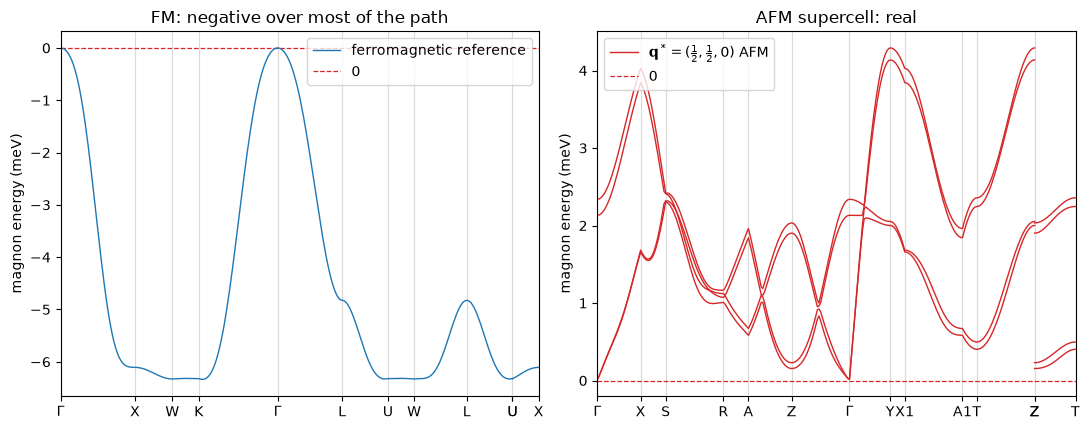

In [14]:
H_SC = sst.load_hamiltonian(afm['dir'] / 'm.fdf')
hr_sc = {sp: sst.lowdin_hamiltonian(H_SC, KG_SC, spin=sp) for sp in (0, 1)}

g_sc = np.meshgrid(*[np.arange(n) for n in KG_SC], indexing='ij')
kpts_sc = np.stack([v.ravel() for v in g_sc], axis=1) / np.array(KG_SC)

# The R cutoff must stay INSIDE the Born-von Karman cell of the k-mesh: J(R)
# from an n1 x n2 x n3 mesh is only defined out to n_i |a_i| / 2, and asking
# for more aliases. That aliasing is not subtle -- pushing R_cut past the limit
# here manufactures magnon modes at -0.2 to -0.7 meV, an order of magnitude
# larger than the physics, which is easy to misread as a real instability.
SC_CELL = SC.get_cell()[:]
BVK = min(n * l for n, l in zip(KG_SC, np.linalg.norm(SC_CELL, axis=1))) / 2.0
R_CUT_SC = min(14.0, BVK)
Rb_sc = np.array([(i, j, k) for i in range(-3, 4) for j in range(-3, 4)
                  for k in range(-3, 4)])
Rl_sc = Rb_sc[np.linalg.norm(Rb_sc @ SC_CELL, axis=1) <= R_CUT_SC]
print(f'Born-von Karman limit for k-grid {KG_SC}: {BVK:.1f} A '
      f'-> R_cut = {R_CUT_SC:.1f} A, {len(Rl_sc)} vectors')

def nd_group(ia, pattern='4f'):
    o = list(H_SC.geometry.a2o(ia, all=True))
    nm = [x.name() for x in H_SC.geometry.atoms[ia].orbitals]
    return [o[k] for k, n_ in enumerate(nm) if pattern in n_]

res_afm = heisenberg_exchange(hr_sc[0], hr_sc[1], kpts_sc, 0.0,
                              [nd_group(ia) for ia in ND_SC], Rl_sc, nz=100)
m_afm = np.asarray(res_afm.magmoms)
print('Nd moments in the AFM cell (mu_B): '
      + '  '.join(f'{v:+.3f}' for v in m_afm))
print(f'  pattern imposed: {SC_SIGN[ND_SC].tolist()}  '
      f'-> realised: {np.sign(m_afm).astype(int).tolist()}')

bp_sc = band_path(SC, npoints=300)
xs, xst, xsl = bp_sc.get_linear_kpoint_axis()
w_afm = magnon_bands(res_afm.J, m_afm, bp_sc.kpts) * HARTREE_TO_EV * 1e3

neg = w_afm[w_afm < -1e-6]
print(f'\nAFM_X magnons: {w_afm.min():+.4f} .. {w_afm.max():+.4f} meV')
print(f'  branches below zero: {neg.size} of {w_afm.size}'
      + (f'   most negative {neg.min():+.4f} meV '
         f'({100 * abs(neg.min()) / w_afm.max():.2f}% of the bandwidth)'
         if neg.size else '  -- the spectrum is REAL'))
w0 = magnon_bands(res_afm.J, m_afm, np.zeros((1, 3))) * HARTREE_TO_EV * 1e3
print(f'  at the zone centre: {np.round(w0[0], 4).tolist()} meV '
      '(the Goldstone modes; numerical zero)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
plot_bands(xm, xmt, [l.replace('G', r'$\Gamma$') for l in xml],
           [BandSeries(w_down, label='ferromagnetic reference', color='C0')],
           ax=axes[0], ref_line=0.0, ref_label='0',
           ylabel='magnon energy (meV)',
           title='FM: negative over most of the path')
plot_bands(xs, xst, [l.replace('G', r'$\Gamma$') for l in xsl],
           [BandSeries(w_afm, label=r'$\mathbf{q}^*=(\frac{1}{2},\frac{1}{2},0)$ AFM',
                       color='C3')],
           ax=axes[1], ref_line=0.0, ref_label='0',
           ylabel='magnon energy (meV)',
           title='AFM supercell: real')
plt.tight_layout(); plt.show()


### What the three tests say

| test | ferromagnet | $\mathbf q^*$ AFM cell |
|---|---|---|
| SCF converges | **no** — 400 iterations, SIESTA exits non-zero | **yes** — 91 iterations |
| energy | no minimum to quote | **lower**, by ~37 meV / 16-atom cell (~9 meV per Nd) |
| magnons | negative over most of the path | **real** |

All three agree, which is the point: any one of them alone would be weak evidence.
That the ferromagnet cannot even be converged while the antiferromagnet drops into
its minimum in 91 iterations, under *identical* numerics, is itself the qualitative
statement — the imaginary modes were not an artifact of the exchange model.

Two honest limits on the energy number.  Only the $M=12$ and $M=15.4$ constrained
points converged, so the lower-$M$ rows are upper bounds and must not be read as
points on a curve; the two that did converge bracket the ferromagnetic moment
($15.3\,\mu_B$) and both lie above the AFM state, with the margin narrowing as $M$
rises.  So 37 meV is best read as an **upper bound** on how much the ferromagnetic
branch could still recover, not a converged energy difference.  It is a small number
— but its sign is the same in every independent test.

The Ag moments collapse from $0.057\,\mu_B$ in the ferromagnetic cell to
$\pm0.001\,\mu_B$ here, so the downfolding question that dominated the previous
section becomes moot in the ground state: there is essentially nothing left on Ag to
fold.  The induced moment was a property of the *wrong* magnetic configuration.

**On reading small negative modes.**  Before trusting "real", check *where* any
negative values sit.  A Goldstone mode must vanish at the zone centre, so a $-0.02$
meV there is numerical zero; a negative mode at general $\mathbf q$ is a genuine
instability.  Here the zone centre is positive and no mode is negative at converged
parameters — but at an under-converged k-mesh this same calculation showed a smooth
dip to $-0.023$ meV along $(111)$, and pushing $R_{\rm cut}$ past the Born–von
Kármán limit produced spurious modes at $-0.19$ and $-0.65$ meV.  Both are
convergence artifacts that mimic a spiral instability, and the cell above pins
$R_{\rm cut}$ to the BvK limit for exactly that reason.


## Adding another compound

Everything above is driven by the config block in the first code cell: a CIF, a
label, and which elements are magnetic sublattices.  The helper below packages
the same sequence so a second compound is one call, and keeps the two guards
that make the result trustworthy — the pseudopotential valence assertion and the
off-mesh interpolation check.

The Nd lesson generalises to the whole lanthanide series: `PP_LANTH` holds the
13 elements whose $4f$ belongs in valence, and every one of them has a
`nc-fr-04_pbe_standard` twin with $4f$ in the core.  `EXPECTED_Z` is what stops
the wrong twin from being used silently.

In [15]:
def pick_pseudo(symbol, want_z, dirs=(PP_LANTH, PP_GENERAL)):
    """
    The pseudopotential file whose valence charge is the one asked for.

    Nd exists in both directories under the same name, with 11 and 14 valence
    electrons -- 4f in the core or in valence -- so picking by directory is how
    the wrong one gets used silently. Picking by valence charge states the
    requirement and checks it in one step: ask for the electrons you need and
    the search either finds them or fails loudly.
    """
    for d in dirs:
        q = pathlib.Path(d) / f'{symbol}.psml'
        if not q.exists():
            continue
        z = float(re.search(r'valence-charge="([\d.]+)"', q.read_text()).group(1))
        if z == want_z:
            return q
    raise FileNotFoundError(
        f'no {symbol}.psml with {want_z} valence electrons in {list(dirs)}')


def magnon_workflow(cif, label, magnetic, expected_z, init_mom, *,
                    downfold=(), kspacing=0.15, mesh_ry=None, basis='DZP',
                    r_cut=None, npoints=300, ncores=16, orbital_filter=None):
    """
    SIESTA -> Loewdin -> LKAG -> LSWT for one compound.

    magnetic : elements kept as magnon branches.
    downfold : elements included in the exchange model but eliminated
               adiabatically -- weakly polarized sites whose spins follow the
               strong ones rather than precessing independently. Their moments
               must be SMALL; a sizeable moment belongs in `magnetic`.
    orbital_filter : {element: substring} restricting a site's orbital group,
               e.g. {'Nd': '4f'}. Elements absent from it use all their NAOs.
    """
    conv = read(cif)
    ci = (conv.get_cell()[:], conv.get_scaled_positions(), conv.get_atomic_numbers())
    lat, pos, num = spglib.standardize_cell(ci, to_primitive=True, symprec=0.1)
    at = Atoms(numbers=num, scaled_positions=pos, cell=lat, pbc=True)
    at = at[np.argsort(-at.get_atomic_numbers())]
    cell, syms = at.get_cell()[:], at.get_chemical_symbols()
    if mesh_ry is None:
        mesh_ry = mesh_cutoff_ry(syms)
    if r_cut is None:
        r_cut = 2.5 * max(np.linalg.norm(cell, axis=1))

    rec = 2 * np.pi * np.linalg.inv(cell).T
    kg = tuple((lambda k: k if k % 2 == 0 else k + 1)(int(np.ceil(l / kspacing)))
               for l in np.linalg.norm(rec, axis=1))

    w = REPO / 'workflows/notebooks/runs' / f'{label}_mesh{int(mesh_ry)}'
    (w / 'pseudos').mkdir(parents=True, exist_ok=True)
    for el in sorted(set(syms)):
        shutil.copy2(pick_pseudo(el, expected_z[el]), w / 'pseudos' / f'{el}.psml')

    f = sst.write_fdf(w / f'{label}.fdf', at, label=label, pseudo_dir=w / 'pseudos',
                      kgrid=kg, spin='polarized', basis=basis, xc='PBE',
                      mesh_cutoff_ry=mesh_ry,
                      initial_moments={i: init_mom.get(el, 0.5)
                                       for i, el in enumerate(syms)},
                      extra={'SCF.Mixer.Method': 'Pulay', 'SCF.Mixer.History': 16,
                             'SCF.Mixer.Weight': 0.4, 'SCF.Mixer.Spin': 'sum',
                             'Max.SCF.Iterations': 200, 'SCFMustConverge': 'T',
                             'Charge.Mulliken': 'end'})
    sst.run_siesta(f, ncores=ncores)
    h = sst.load_hamiltonian(w / f'{label}.fdf')
    hrs = {sp: sst.lowdin_hamiltonian(h, kg, spin=sp) for sp in (0, 1)}

    path = band_path(at, npoints=npoints)
    ref = np.array([h.eigh(k, spin=0) for k in path.kpts])
    fid = band_path_fidelity(band_eigensystem(hrs[0], path.kpts)[0] * HARTREE_TO_EV,
                             ref, window=(-3.0, 3.0), fermi_ev=0.0)

    gm = np.meshgrid(*[np.arange(n) for n in kg], indexing='ij')
    kp = np.stack([v.ravel() for v in gm], axis=1) / np.array(kg)
    rr = range(-3, 4)
    Rb = np.array([(i, j, k) for i in rr for j in rr for k in rr])
    rl = Rb[np.linalg.norm(Rb @ cell, axis=1) <= r_cut]

    keep = [i for i, el in enumerate(syms) if el in magnetic]
    fold = [i for i, el in enumerate(syms) if el in downfold]
    order = keep + fold                       # kept sublattices first
    grp = []
    for ia in order:
        o = list(h.geometry.a2o(ia, all=True))
        pat = (orbital_filter or {}).get(syms[ia])
        if pat:
            nm = [x.name() for x in h.geometry.atoms[ia].orbitals]
            o = [o[k] for k, n_ in enumerate(nm) if pat in n_]
        grp.append(o)
    ex = heisenberg_exchange(hrs[0], hrs[1], kp, 0.0, grp, rl, nz=100)
    fold_idx = list(range(len(keep), len(order)))
    om = magnon_bands(ex.J, np.asarray(ex.magmoms), path.kpts,
                      downfold=fold_idx or None) * HARTREE_TO_EV * 1e3
    return dict(atoms=at, cell=cell, kgrid=kg, mesh_ry=mesh_ry, H=h, hr=hrs,
                fidelity=fid, exchange=ex, omega=om, path=path,
                sublattices=[f'{syms[i]}{i}' for i in order], n_kept=len(keep))


print(magnon_workflow.__doc__)


    SIESTA -> Loewdin -> LKAG -> LSWT for one compound.

    magnetic : elements kept as magnon branches.
    downfold : elements included in the exchange model but eliminated
               adiabatically -- weakly polarized sites whose spins follow the
               strong ones rather than precessing independently. Their moments
               must be SMALL; a sizeable moment belongs in `magnetic`.
    orbital_filter : {element: substring} restricting a site's orbital group,
               e.g. {'Nd': '4f'}. Elements absent from it use all their NAOs.
    


# A second compound: MgCoNi$_2$O$_4$, where nothing may be downfolded

Ag$_2$NdCd is the case where one species carries the magnetism and a second is
weakly induced, so the induced one had to be folded away.  MgCoNi$_2$O$_4$
(monoclinic $P2/m$, 8 atoms) is the opposite: **Co and Ni both carry sizeable
$3d$ moments**, and folding either into the other would be throwing away a real
degree of freedom, not removing an artifact.  The magnon spectrum genuinely has
one branch per magnetic atom.

What *is* a downfolding candidate here is oxygen.  In an oxide the ligand picks
up an induced moment and mediates superexchange between the transition-metal
sites — the same role iodine plays in NiI$_2$, where folding it in changed
$J_1$ by ~90$	imes$.  So the roles swap relative to the first compound: three
$3d$ sites stay as branches, four O sites are computed and folded.

The criterion is the **moment ratio**, not the element.  A site whose moment is
comparable to the others precesses on the same energy scale and must be kept; a
site an order of magnitude weaker produces a branch at $J/\sqrt{S}$ far above
the physics of interest and should be folded.  Both compounds are run through
the same function, differing only in which elements go in `magnetic` and which
in `downfold`.

**Status.**  The SCF for this compound does not converge: with a ferromagnetic
start the moment oscillates between ~9.5 and ~11.5 $\mu_B$ and the density never
settles, at mixer weights from 0.4 down to 0.05 and out to 600 iterations.  That
is a physical bistability, two magnetic states a couple of $\mu_B$ apart, not a
numerical setting — consistent with a Co/Ni oxide whose ground state is not the
ferromagnet the calculation was started in.  It needs a fixed-spin-moment scan
or an antiferromagnetic starting configuration, so it is left out here rather
than reported half-converged.  `magnon_workflow` below is what it will be run
through once that is settled.